In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


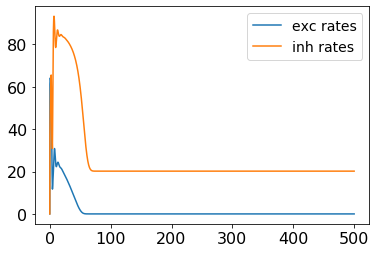

[5.3067e-05 2.0196e+01]


In [2]:
aln = ALNModel()

aln.params['duration'] = 500.

# no noise
aln.params.sigma_ou = 0.

control0 = aln.getZeroControl()

# external currents for steady state
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()
    
steady_rates = np.zeros((2))
steady_rates[0] = aln.rates_exc[0,-1]
steady_rates[1] = aln.rates_inh[0,-1]

print(steady_rates)

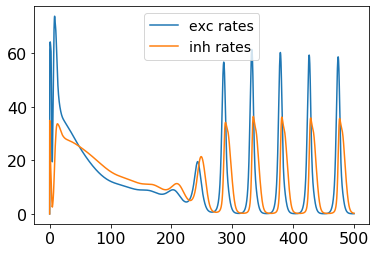

In [3]:
# external currents for oscillation
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 0.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

state_vars = aln.state_vars

osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        osc_init[i] = aln.state[state_vars[i]][0]
    else:
        osc_init[i] = aln.state[state_vars[i]][0,-1]

In [4]:
init_vars = aln.init_vars

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

In [13]:
dur = 20.
dur_pre = 100.
dur_post = 500.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = steady_rates[0]
target[:,1,:] = steady_rates[1] 

max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

## A)
- adaptation
- default delay
- max control current 5nA
- w_p = w_e = w_s = 1

In [14]:
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.

setinitvars(osc_init)
max_it = 1
alg = "A2"
case = "A"

opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "alg": alg,
}

control0 = aln.getZeroControl()
#control0 = bestControlA[:,:,2000:7001]

if alg == "A1":
    bestControlA, bestStateA, costA, runtimeA = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
elif alg == "A2":
    bestControlA, bestStateA, costA, runtimeA = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultA = {"Opt_control": bestControlA,
          "Opt_state": bestStateA,
          "costArray": costA,
          "runtimeArray": runtimeA,    
}

dump_dicts = [opt_params, aln.params, resultA]
filename = str(case + "_" + alg + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
True 40
RUN  0 , total integrated cost:  11170.097807475053
RUN  1 , total integrated cost:  2646.239171182114
Improved over  1  iterations by  77  percent.


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -63.129047688158366 -63.07610419907662
Problem in initial value trasfer:  Vmean_exc -62.90411739651571 -63.01616821722484


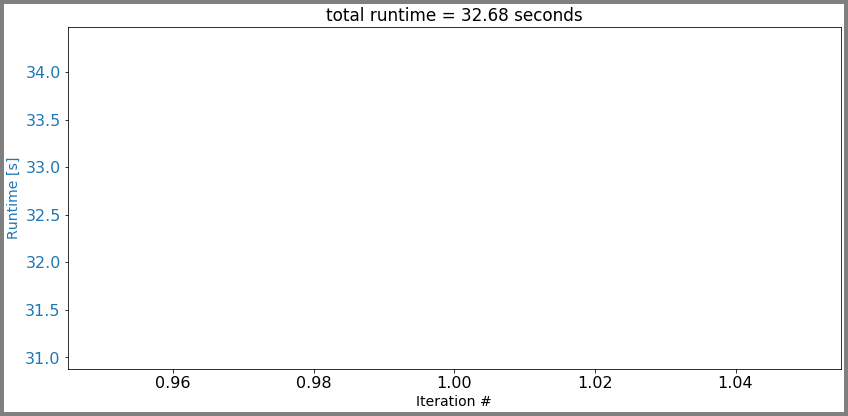

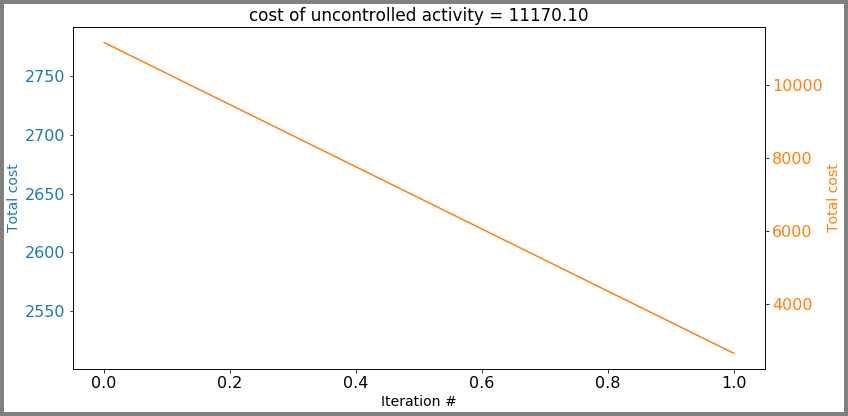

In [15]:
plotFunc.plot_runtime(runtimeA, path, str("p1_e1_s1_u1nA_OscSteady_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA, path, str("p1_e1_s1_u1nA_OscSteady_cost_" + case + "_" + alg) )

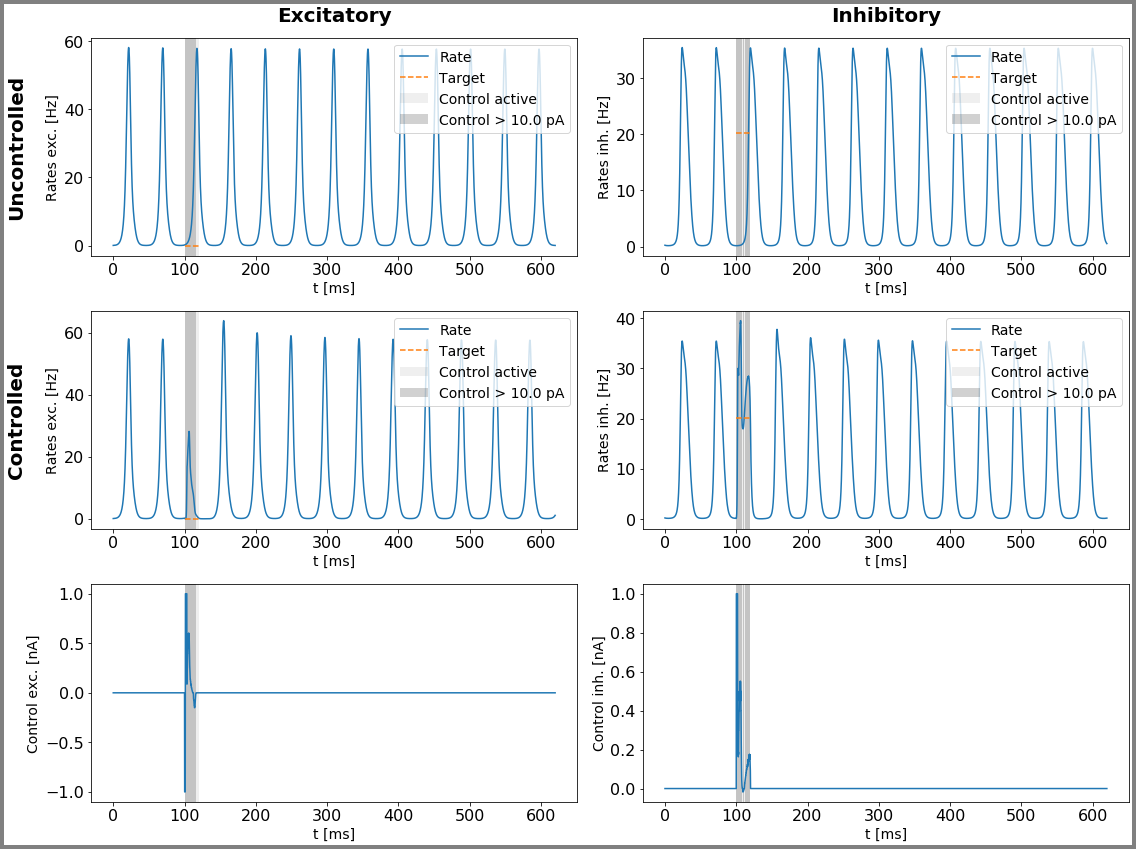

In [16]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, osc_init, target,
                      path, filename_ = str('p1_e1_s1_u1nA_OscSteady_' + case + "_" + alg))